In [82]:
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv

In [83]:
load_dotenv()

True

In [84]:
model=ChatGroq(model='openai/gpt-oss-120b',max_tokens=999)

In [85]:
class BlogState(TypedDict):
   topic:str
   outline:str 
   content:str
   evaluate:str

In [86]:
def create_outline(state:BlogState) -> BlogState:
    
    #extract the topic from the state
    topic=state['topic']
    
    #form a prompt
    prompt=f"Genearte an outline for a blog on the topic - {topic}"
    
    #ask qsn to llm
    outline=model.invoke(prompt).content
    
    #update the answer in state
    state['outline']=outline
    
    
    return state


In [ ]:
def create_blog(state:BlogState) -> BlogState:
    
    #extract the title and outline from the state
    topic=state['topic']
    outline=state['outline']
    
    #form a prompt
    prompt=f"Generate a blog on the topic  - {topic} \n  by using a  outline - {outline}"
    
    
    #ask qsn to llm
    blog=model.invoke(prompt).content
    
    #update the answer in state
    state['content']=blog
    
    
    return state


In [88]:
def evalaute_blog(state:BlogState) -> BlogState:
    
    #extract the title and outline from the state
    topic=state['topic']
    blog=state['content']
    
    #form a prompt
    prompt=f"Rate  this blog - \n {blog} \n on the topic  - {topic} ,and IMportant:GIve me the intger score out of 10 and a resonable explanation having suggestions and improvement "
    
    
    #ask qsn to llm
    evalaute=model.invoke(prompt).content
    
    #update the answer in state
    state['evaluate']=evalaute
    
    
    return state


In [89]:
#create graph 
graph=StateGraph(BlogState)

#create node
graph.add_node('create_outline',create_outline)
graph.add_node('create_blog',create_blog)
graph.add_node('evalaute_blog',evalaute_blog)


#create edge
graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','create_blog')
graph.add_edge('create_blog','evalaute_blog')
graph.add_edge('evalaute_blog',END)

#compile graph

workflow=graph.compile()

In [90]:
#execute the graph
initial_state={'topic':'Nepal Mountains'}
final_state=workflow.invoke(initial_state)

In [91]:
print(final_state['outline'])

**Blog Title (Working):** *“Exploring the Majestic Nepal Mountains: A Traveler’s Guide, Cultural Journey, and Conservation Call‑to‑Action”*  

---

## 1. Introduction  
- **Hook:** A vivid, sensory snapshot (e.g., sunrise over Annapurna, the roar of the Khumbu Glacier).  
- **Why Nepal’s mountains matter:** UNESCO World Heritage, biodiversity hotspot, spiritual heartland, adventure capital.  
- **Brief roadmap:** What readers will learn (geography, trekking routes, culture, wildlife, practical tips, responsible travel).  

---

## 2. Geographic Overview  
### 2.1. The Himalayan Backbone  
- Overview of the Himalayas as a whole; Nepal’s share (≈ 75 % of the world’s 8,000‑m peaks).  
- Major sub‑ranges: Mahalangur, Annapurna, Dhaulagiri, Manaslu, Langtang, and the “Mid‑Hills.”  

### 2.2. Iconic Peaks  
| Peak | Elevation | Notable Fact |
|------|-----------|--------------|
| Mount Everest (Sagarmatha) | 8,848 m | World’s highest point |
| Kanchenjunga (Kangchenjunga) | 8,586 m | 2nd hig

In [92]:
print(final_state['content'])

**Exploring the Majestic Nepal Mountains: A Traveler’s Guide, Cultural Journey, and Conservation Call‑to‑Action**

---

**1. Introduction**  
Imagine the first light of dawn spilling over the snow‑capped ridge of Annapurna, while the distant roar of the Khumbu Glacier echoes through the valley. This is the everyday magic of Nepal’s mountains—a place where the world’s highest peaks meet ancient spirituality, unrivaled biodiversity, and the pulse of adventure. Recognised as a UNESCO World Heritage site and a global hotspot for rare flora and fauna, the Nepali Himalaya also serves as the spiritual heartland for millions and the playground for trekkers from every corner of the globe. In the pages that follow you will discover the geography of these towering ranges, the classic trekking routes, the cultures that call the highlands home, the wildlife that roams the slopes, practical travel tips, and ways you can help protect this fragile environment.

**2. Geographic Overview**  

*The Himal

In [94]:
print(final_state['evaluate'])

**Score: 7 / 10**

---

## Why it earned a 7

| Aspect | What works well | Where it falls short |
|--------|----------------|----------------------|
| **Structure & Flow** | Clear headings (Intro, Geographic Overview, Culture, Trekking) make it easy to skim. The logical progression—from big‑picture geography to cultural depth to practical trekking info—helps readers stay oriented. | The transition between sections can feel abrupt. A brief “what’s coming next” sentence after each major heading would smooth the reading experience. |
| **Content Depth** | Provides solid factual nuggets (peak elevations, glacier‑river link, ethnic groups, festival names). The inclusion of a table for peaks and a trekking‑summary table is a nice visual aid. | Some sections are surface‑level. For example, the “Cultural & Spiritual Significance” paragraph lists groups and festivals but doesn’t give any context (e.g., why Mani Rimdu matters, how festivals affect daily life). Adding a sentence or two of storyte

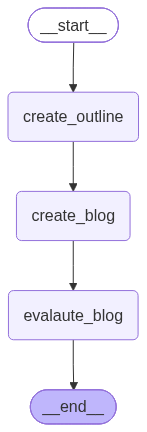

In [95]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())